# Figure 4 — effect of opt1 (`-O0` → `-O3`) in isolation

Self-contained: every measured number is inline below, so this notebook needs
nothing from the repository except a place to write the output.

**Kernel:** the `mp1` conda environment (matplotlib + numpy).

## Where the numbers come from

Produced by `bench/opt1_ablation.sh`, Part A, on Slurm compute node `sprc01`
(AMD EPYC 9334), g++ 11.4.0, single thread, median of 3 runs, each workload at
1024×1024. The only difference between the two builds is the `-O` level in
`src/Makefile`; `-march=native`, `-fno-math-errno`, `-funroll-loops` and
`-fopenmp` are identical in both, and every other optimization (opt2–opt10) is
present in both.

To re-measure rather than re-plot:

```bash
srun -p debug -N1 -c8 --mem=32G bench/opt1_ablation.sh
```

## Layout

Follows Fig. 9 of arXiv:2602.07223: one facet per workload with its own linear
axis from zero (a shared axis would flatten the sphere-mesh bars, which are ~28×
smaller than pianoroom's), a value printed on every bar, one speedup label per
facet above the optimized bar, and a single shared legend row underneath.


In [92]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print('matplotlib', matplotlib.__version__, '| numpy', np.__version__)


def find_figures_dir(start: Path | None = None) -> Path:
    """Locate <repo>/report/figures, walking up from the notebook or cwd."""
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / 'bench').is_dir() and (cand / 'main.cpp').is_file():
            out = cand / 'report' / 'figures'
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = here / 'figures'          # fallback: write next to the notebook
    out.mkdir(parents=True, exist_ok=True)
    return out


FIGDIR = find_figures_dir()
print('writing to', FIGDIR)

matplotlib 3.11.1 | numpy 2.5.3
writing to /home/yikang/cs598ape/hw1/report/figures


## Measured data

Three build configurations, single thread, median of 3, from
`bench/three_way.sh`. Edit these to re-render.

In [93]:
# --- Figure 4: three-way comparison (bench/three_way.sh) --------------------
# Single thread, median of 3, one job on sprc01. pianoroom/globe at 1000x1000; sphere mesh
# at 100x100. 1000 rather than 1024 because the baseline and opt1 commits predate
# the image-buffer fix and overflow DATA above 1000x1000. The real elephant is
# absent: with 111748 triangles the supplied code needs ~10 s per ray, so its
# baseline bar is unmeasurable at any useful resolution.
CONFIGS = ["Baseline", "-O3 only", "-O3 w/ all remaining optimizations"]
# How many of CONFIGS to draw. 2 = baseline and -O3 only; set to 3 to bring
# back the fully optimized bar (its data stays measured either way).
SHOW = 2

WL = ["Pianoroom 1000×1000", "Globe 1000×1000", "Sphere mesh 100×100"]
TIMES = np.array([
    [5.985856, 3.185177, 0.461509],   # pianoroom
    [4.775890, 2.697881, 1.041259],   # globe
    [80.834862, 15.939255, 0.003749],
])

for name, row in zip(WL, TIMES):
    base = row[0]
    print(f"{name.splitlines()[0]:<12} "
          + "  ".join(f"{v:9.4f}s" for v in row)
          + "   speedups: " + ", ".join(f"{base / v:,.2f}x" for v in row[1:]))

Pianoroom 1000×1000    5.9859s     3.1852s     0.4615s   speedups: 1.88x, 12.97x
Globe 1000×1000    4.7759s     2.6979s     1.0413s   speedups: 1.77x, 4.59x
Sphere mesh 100×100   80.8349s    15.9393s     0.0037s   speedups: 5.07x, 21,561.71x


## Style

Times New Roman when the machine has it. `STIXGeneral` is metrically compatible
and ships with matplotlib, so the figure looks the same without installing fonts.
`pdf.fonttype = 42` embeds TrueType instead of Type 3, which some conference and
arXiv pipelines reject.


In [94]:
# Ablation palette: slower (unoptimized) vs faster (optimized) build.
SLOW, FAST = "#343535", "#ffb830"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    # Times New Roman if the machine has it; STIXGeneral is metric-compatible and
    # ships with matplotlib, so the figures look the same without installing fonts.
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Nimbus Roman",
                   "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,   # embed as TrueType, not Type 3
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2,
    "ytick.color": INK2, "ytick.labelsize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "figure.dpi": 200,
})

# bar fills, in the order the configurations appear
BAR_COLORS = [SLOW, FAST, "#ffffff"]

# Report which font actually resolved: matplotlib substitutes silently,
# and Times New Roman is absent on these machines.
from matplotlib.font_manager import FontProperties, findfont
print('serif resolves to:', Path(findfont(FontProperties(family='serif'))).name)

serif resolves to: STIXGeneral.ttf


## The figure


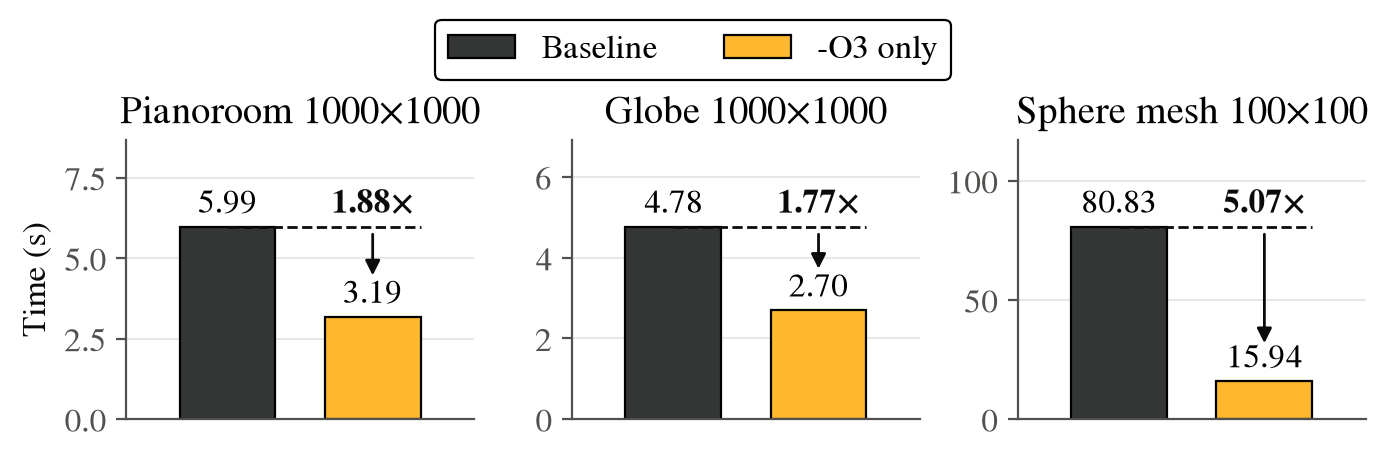

In [95]:
def make_figure(width=7.0, height=2):
    fig, axes = plt.subplots(1, len(WL), figsize=(width, height))

    for ax, name, row in zip(axes, WL, TIMES):
        bars = ax.bar(np.arange(SHOW), row[:SHOW], 0.66, color=BAR_COLORS[:SHOW],
                      edgecolor="black", linewidth=0.8)
        ax.set_ylim(0, row[:SHOW].max() * 1.45)
        ax.set_xlim(-0.7, SHOW - 0.3)
        ax.set_xticks([])
        ax.set_title(name, fontsize=14)
        ax.grid(axis="x", visible=False)

        for rect, v in zip(bars, row[:SHOW]):
            ax.annotate(f"{v:.2f}" if v >= 0.01 else f"{v:.4f}",
                        xy=(rect.get_x() + rect.get_width() / 2, v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=12, color="black")
        ax.plot([0, bars[-1].get_x() + bars[-1].get_width()], [row[0], row[0]],
                linestyle=(0, (3.7, 1.6)), color=INK, linewidth=1.0, zorder=3)
        for i in range(1, SHOW):
            r = row[0] / row[i]
            label = f"{r:,.0f}×" if r >= 100 else f"{r:.2f}×"
            ax.annotate("", xy=(i, row[i] * 1.05), xytext=(i, row[0] * 0.96),
                        arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.0,
                                        shrinkA=0, shrinkB=13, mutation_scale=11),
                        zorder=3)
            ax.annotate(label, xy=(i, row[0]), xytext=(0, +14),
                        textcoords="offset points", ha="center", va="top",
                        fontsize=12, fontweight="bold", color=INK, zorder=4,
                        bbox=dict(boxstyle="square,pad=0.15", facecolor="none",
                                  edgecolor="none"))

    axes[0].set_ylabel("Time (s)", fontsize=12)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor="black", linewidth=0.8)
               for c in BAR_COLORS[:SHOW]]
    leg = fig.legend(handles, [c.replace("\n", " ") for c in CONFIGS[:SHOW]],
                     loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.16),
                     fontsize=12, frameon=True, edgecolor="black", framealpha=1.0)
    leg.get_frame().set_linewidth(0.8)
    fig.tight_layout()
    return fig


fig = make_figure()

## Save

Writes `fig4_opt1_ablation.pdf` and `.png` into `report/figures/`, overwriting
the versions produced by `report/make_figures.py`. Use the PDF in LaTeX.


In [96]:
paths = []
for ext in ('pdf', 'png'):
    p = FIGDIR / f'opt1_o3.{ext}'
    fig.savefig(p, bbox_inches='tight')
    paths.append(p)

for p in paths:
    print(f'{p}  ({p.stat().st_size / 1024:.1f} KiB)')

/home/yikang/cs598ape/hw1/report/figures/opt1_o3.pdf  (11.6 KiB)
/home/yikang/cs598ape/hw1/report/figures/opt1_o3.png  (56.1 KiB)


## Sizing for the paper

Text is 9 pt *at the figure's native size*, so `\includegraphics` scaling changes
the effective point size. At 7.0 in it fills a two-column SIGPLAN text block with
no scaling. For a single column (~3.3 in), do not scale this figure down — labels
would land near 4 pt. Instead rebuild at the target width:

```python
fig = make_figure(width=3.3, height=2.6)   # then re-run the save cell
```

The other three report figures are produced by `report/make_figures.py`, which
shares this styling.
